<a href="https://colab.research.google.com/github/Hamerson-jhoel/Teoria_de_senales/blob/main/Taller23SEP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Taller 23 sep

#Hamerson joel piarpuezan

#Código con las estimcaciones coseno y mayor incertidumbre

=== PARÁMETROS REALES ===
Amplitud: 2.0
Frecuencia: 5.0 Hz
Fase: 0.785 rad

=== ESTIMACIONES ===
Método A (coseno simple):
  Amplitud: -1.971 (err: 3.971)
  Frecuencia: 4.999 Hz (err: 0.001)
  Fase: -2.353 rad (err: 3.138)

Método B (cos+sen):
  Amplitud: 1.971 (err: 0.029)
  Frecuencia: 4.999 Hz (err: 0.001)
  Fase: 0.789 rad (err: 0.003)

Método C (FFT):
  Amplitud: 1.971 (err: 0.029)
  Frecuencia: 4.995 Hz (err: 0.005)
  Fase: 0.815 rad (err: 0.030)


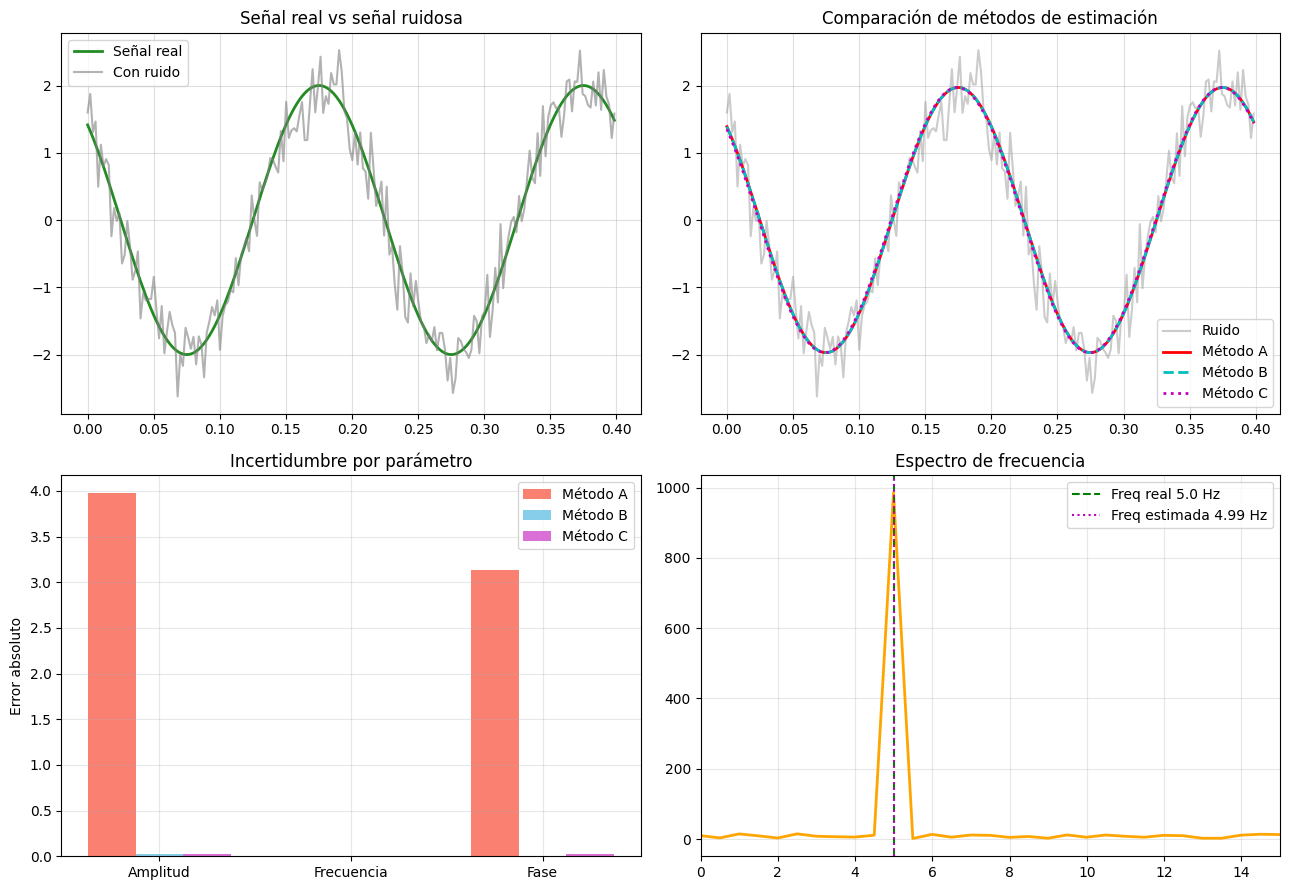


=== ANÁLISIS DE INCERTIDUMBRE ===
Amplitud: mayor incertidumbre en Método A (err=3.971)
Frecuencia: mayor incertidumbre en Método C (err=0.005)
Fase: mayor incertidumbre en Método A (err=3.138)


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.fft import fft, fftfreq

# ===============================
# Parámetros reales de referencia
# ===============================
amp_real = 2.0
f_real = 5.0              # Hz
w_real = 2*np.pi*f_real   # rad/s
phi_real = np.pi/4
sigma_ruido = 0.3

# ===============================
# Generar señal con ruido
# ===============================
t = np.linspace(0, 2, 1000)
senal_limpia = amp_real * np.cos(w_real * t + phi_real)
ruido = np.random.normal(0, sigma_ruido, len(t))
x = senal_limpia + ruido

print("=== PARÁMETROS REALES ===")
print(f"Amplitud: {amp_real}")
print(f"Frecuencia: {f_real} Hz")
print(f"Fase: {phi_real:.3f} rad")

# ===============================
# Método A: Ajuste de un coseno
# ===============================
def modelo_cos(t, a, w, phi):
    return a * np.cos(w*t + phi)

poptA, _ = curve_fit(modelo_cos, t, x, p0=[2, 30, 0])
aA, wA, phiA = poptA

# ===============================
# Método B: Coseno + Seno
# ===============================
def modelo_seno_cos(t, A, B, w):
    return A*np.cos(w*t) + B*np.sin(w*t)

poptB, _ = curve_fit(modelo_seno_cos, t, x, p0=[1, 1, 30])
A, B, wB = poptB
aB = np.sqrt(A**2 + B**2)
phiB = np.arctan2(-B, A)

# ===============================
# Método C: Basado en FFT
# ===============================
fft_x = fft(x)
freqs = fftfreq(len(t), t[1]-t[0])
idx = np.argmax(np.abs(fft_x[1:len(freqs)//2])) + 1
fC = abs(freqs[idx])
wC = 2*np.pi*fC

def modelo_fijo(t, a, phi):
    return a*np.cos(wC*t + phi)

poptC, _ = curve_fit(modelo_fijo, t, x, p0=[2, 0])
aC, phiC = poptC

# ===============================
# Cálculo de errores
# ===============================
def calc_err():
    return {
        "A_amp": abs(aA - amp_real),
        "A_freq": abs(wA/(2*np.pi) - f_real),
        "A_phi": abs(phiA - phi_real),
        "B_amp": abs(aB - amp_real),
        "B_freq": abs(wB/(2*np.pi) - f_real),
        "B_phi": abs(phiB - phi_real),
        "C_amp": abs(aC - amp_real),
        "C_freq": abs(fC - f_real),
        "C_phi": abs(phiC - phi_real)
    }

errores = calc_err()

# ===============================
# Mostrar resultados
# ===============================
print("\n=== ESTIMACIONES ===")
print("Método A (coseno simple):")
print(f"  Amplitud: {aA:.3f} (err: {errores['A_amp']:.3f})")
print(f"  Frecuencia: {wA/(2*np.pi):.3f} Hz (err: {errores['A_freq']:.3f})")
print(f"  Fase: {phiA:.3f} rad (err: {errores['A_phi']:.3f})")

print("\nMétodo B (cos+sen):")
print(f"  Amplitud: {aB:.3f} (err: {errores['B_amp']:.3f})")
print(f"  Frecuencia: {wB/(2*np.pi):.3f} Hz (err: {errores['B_freq']:.3f})")
print(f"  Fase: {phiB:.3f} rad (err: {errores['B_phi']:.3f})")

print("\nMétodo C (FFT):")
print(f"  Amplitud: {aC:.3f} (err: {errores['C_amp']:.3f})")
print(f"  Frecuencia: {fC:.3f} Hz (err: {errores['C_freq']:.3f})")
print(f"  Fase: {phiC:.3f} rad (err: {errores['C_phi']:.3f})")

# ===============================
# Señales estimadas
# ===============================
xA = modelo_cos(t, aA, wA, phiA)
xB = modelo_seno_cos(t, A, B, wB)
xC = modelo_fijo(t, aC, phiC)

# ===============================
# Gráficas
# ===============================
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(13, 9))

# Señal real y con ruido
ax1.plot(t[:200], senal_limpia[:200], 'forestgreen', lw=2, label='Señal real')
ax1.plot(t[:200], x[:200], 'gray', alpha=0.6, label='Con ruido')
ax1.set_title("Señal real vs señal ruidosa")
ax1.legend(); ax1.grid(alpha=0.4)

# Comparación de estimaciones
ax2.plot(t[:200], x[:200], '0.6', label='Ruido', alpha=0.5)
ax2.plot(t[:200], xA[:200], 'r-', lw=2, label='Método A')
ax2.plot(t[:200], xB[:200], 'c--', lw=2, label='Método B')
ax2.plot(t[:200], xC[:200], 'm:', lw=2, label='Método C')
ax2.set_title("Comparación de métodos de estimación")
ax2.legend(); ax2.grid(alpha=0.4)

# Barras de error
componentes = ["Amplitud", "Frecuencia", "Fase"]
err_A = [errores["A_amp"], errores["A_freq"], errores["A_phi"]]
err_B = [errores["B_amp"], errores["B_freq"], errores["B_phi"]]
err_C = [errores["C_amp"], errores["C_freq"], errores["C_phi"]]

xpos = np.arange(len(componentes))
ax3.bar(xpos-0.25, err_A, width=0.25, color='salmon', label="Método A")
ax3.bar(xpos, err_B, width=0.25, color='skyblue', label="Método B")
ax3.bar(xpos+0.25, err_C, width=0.25, color='orchid', label="Método C")
ax3.set_xticks(xpos); ax3.set_xticklabels(componentes)
ax3.set_ylabel("Error absoluto")
ax3.set_title("Incertidumbre por parámetro")
ax3.legend(); ax3.grid(alpha=0.3)

# Espectro FFT
freqs_pos = freqs[:len(freqs)//2]
fft_pos = np.abs(fft_x)[:len(freqs)//2]
ax4.plot(freqs_pos, fft_pos, color='orange', lw=2)
ax4.axvline(f_real, color='g', ls='--', label=f"Freq real {f_real} Hz")
ax4.axvline(fC, color='m', ls=':', label=f"Freq estimada {fC:.2f} Hz")
ax4.set_xlim(0, 15)
ax4.set_title("Espectro de frecuencia")
ax4.legend(); ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ===============================
# Análisis de incertidumbre
# ===============================
print("\n=== ANÁLISIS DE INCERTIDUMBRE ===")
metodos = {"Método A": err_A, "Método B": err_B, "Método C": err_C}

for i, comp in enumerate(componentes):
    peor = max(metodos, key=lambda k: metodos[k][i])
    print(f"{comp}: mayor incertidumbre en {peor} (err={metodos[peor][i]:.3f})")


#Análisis de Señales Armónicas con Ruido: Estimación de PSD, Autocorrelación y Estadísticos Básicos

/tmp/ipython-input-240123080.py:87: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  power_welch_1 = np.trapz(Pxx_w1, f_w1)
/tmp/ipython-input-240123080.py:88: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  power_welch_2 = np.trapz(Pxx_w2, f_w2)


===== Estadísticos temporales =====
Señal 1 (1 armónico + ruido): mean = -0.005266, var (muestral) = 1.343086, potencia (Welch area) ≈ 1.349023
Señal 2 (3 armónicos + ruido): mean = -0.006114, var (muestral) = 1.386339, potencia (Welch area) ≈ 1.439908



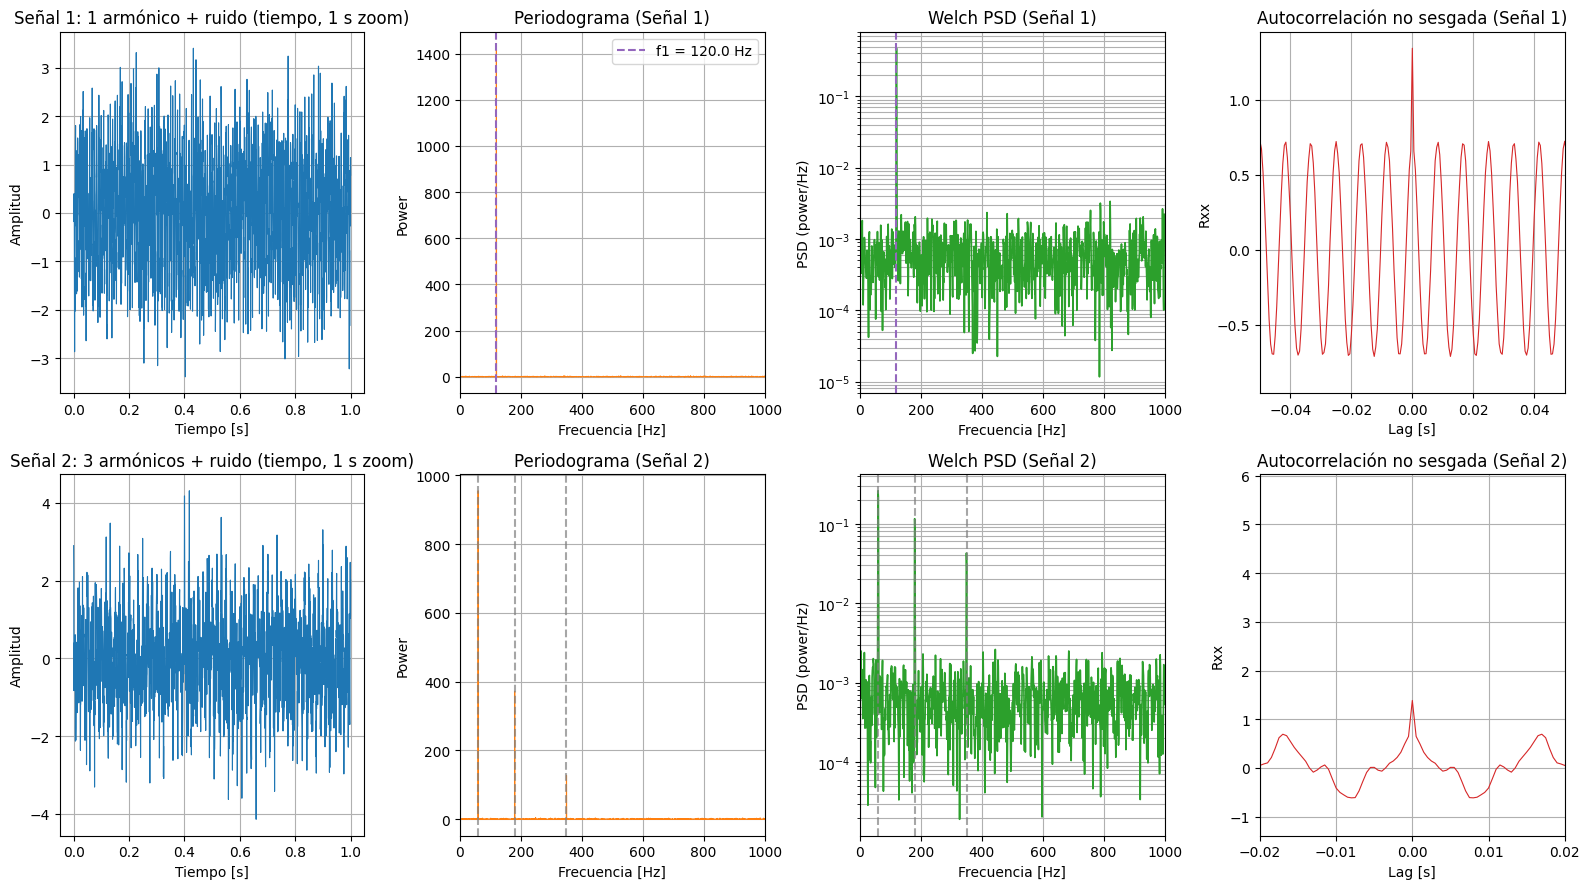

Interpretación rápida:
- En las PSD (Welch) busca picos cerca de las frecuencias fundamentales (f1, f2, f3).
- La autocorrelación muestra periodicidad: los retardos con máximos indican los periodos dominantes.
- La media y varianza impresas arriba son del dominio del tiempo (útiles para caracterizar ruido).
- El valor 'potencia (Welch area)' aproxima la energía total (integral S_x(f) df).


In [1]:
# Análisis: 1 armónico + ruido  vs  3 armónicos + ruido
# - Generación en PyTorch (reproducible)
# - Periodograma (FFT) y Welch (PSD)
# - Autocorrelación no sesgada
# - Estadísticos (media, varianza, potencia total)
# - Gráficas limpias con marcas en frecuencias fundamentales

import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# -------------------- Parámetros --------------------
torch.manual_seed(0)
np.random.seed(0)

fs = 2000          # frecuencia de muestreo (Hz)
T = 2.0            # duración (s)
N = int(fs * T)    # número de muestras
t = torch.arange(N, dtype=torch.float32) / fs

# Ruido (ajusta para ver más/menos ocultamiento del armónico)
noise_std = 0.8

# -------------------- Señal A: 1 armónico + ruido --------------------
A1 = 1.2
f1 = 120.0    # Hz (fundamental)
phi1 = 0.3    # rad
sig1 = A1 * torch.cos(2 * torch.pi * f1 * t + phi1) + noise_std * torch.randn(N)

# -------------------- Señal B: 3 armónicos + ruido --------------------
A_list = [1.0, 0.6, 0.35]
f_list = [60.0, 180.0, 350.0]   # Hz (asegúrate < fs/2)
phi_list = [0.0, 0.5, -0.2]
sig2 = (A_list[0]*torch.cos(2*np.pi*f_list[0]*t + phi_list[0]) +
        A_list[1]*torch.cos(2*np.pi*f_list[1]*t + phi_list[1]) +
        A_list[2]*torch.cos(2*np.pi*f_list[2]*t + phi_list[2]) +
        noise_std * torch.randn(N))

# -------------------- Utilidades --------------------
def periodogram_psd_one_sided(x, fs):
    """Periodograma one-sided usando rFFT. Devuelve freqs>=0 y PSD (power per bin)."""
    x = np.asarray(x)
    Nloc = x.size
    Xr = np.fft.rfft(x)
    freqs = np.fft.rfftfreq(Nloc, d=1/fs)
    psd = (np.abs(Xr)**2) / Nloc      # periodograma (power per bin)
    return freqs, psd

def autocorr_unbiased(x):
    """Autocorrelación no sesgada (centrada). Devuelve lags (s) y rxx."""
    x = np.asarray(x)
    Nloc = x.size
    xm = x.mean()
    xc = x - xm
    r = np.correlate(xc, xc, mode='full')   # length 2N-1
    lags = np.arange(-Nloc+1, Nloc)
    denom = (Nloc - np.abs(lags))           # unbiased denominator
    r_unbiased = r / denom
    lags_seconds = lags / fs
    return lags_seconds, r_unbiased

def compute_welch(x, fs, nperseg=2048, noverlap=None):
    """Welch PSD (one-sided)."""
    f, Pxx = welch(x, fs=fs, nperseg=nperseg, noverlap=noverlap)
    return f, Pxx

# -------------------- Convertir a numpy para cómputos (Welch usa numpy arrays) ----
x1 = sig1.cpu().numpy()
x2 = sig2.cpu().numpy()

# -------------------- Estadística tiempo (media y varianza) --------------------
mean1 = x1.mean()
var1 = x1.var(ddof=1)
mean2 = x2.mean()
var2 = x2.var(ddof=1)

# -------------------- Periodograma (FFT) --------------------
freqs_p1, psd_p1 = periodogram_psd_one_sided(x1, fs)
freqs_p2, psd_p2 = periodogram_psd_one_sided(x2, fs)

# -------------------- Welch --------------------
f_w1, Pxx_w1 = compute_welch(x1, fs, nperseg=2048, noverlap=1024)
f_w2, Pxx_w2 = compute_welch(x2, fs, nperseg=2048, noverlap=1024)

# Potencia total aproximada (área bajo la PSD de Welch)
power_welch_1 = np.trapz(Pxx_w1, f_w1)
power_welch_2 = np.trapz(Pxx_w2, f_w2)

# -------------------- Autocorrelación no sesgada --------------------
lags1, rxx1 = autocorr_unbiased(x1)
lags2, rxx2 = autocorr_unbiased(x2)

# -------------------- Imprimir resultados numéricos --------------------
print("===== Estadísticos temporales =====")
print(f"Señal 1 (1 armónico + ruido): mean = {mean1:.6f}, var (muestral) = {var1:.6f}, potencia (Welch area) ≈ {power_welch_1:.6f}")
print(f"Señal 2 (3 armónicos + ruido): mean = {mean2:.6f}, var (muestral) = {var2:.6f}, potencia (Welch area) ≈ {power_welch_2:.6f}")
print()

# -------------------- Gráficas (organizadas) --------------------
plt.figure(figsize=(16, 9))

# --- Señal 1: tiempo (zoom primeros 1s) ---
ax = plt.subplot(2,4,1)
ax.plot(t[:int(fs*1.0)].numpy(), x1[:int(fs*1.0)], color='C0', linewidth=0.8)
ax.set_title("Señal 1: 1 armónico + ruido (tiempo, 1 s zoom)")
ax.set_xlabel("Tiempo [s]"); ax.set_ylabel("Amplitud"); ax.grid(True)

# --- Señal 1: periodograma ---
ax = plt.subplot(2,4,2)
ax.plot(freqs_p1, psd_p1, color='C1', linewidth=0.8)
ax.set_title("Periodograma (Señal 1)")
ax.set_xlabel("Frecuencia [Hz]"); ax.set_ylabel("Power")
ax.set_xlim(0, fs/2); ax.grid(True)
# marcar la frecuencia fundamental
ax.axvline(f1, color='C4', linestyle='--', label=f'f1 = {f1} Hz')
ax.legend()

# --- Señal 1: Welch (log scale y marca f1) ---
ax = plt.subplot(2,4,3)
ax.semilogy(f_w1, Pxx_w1, color='C2', linewidth=1.2)
ax.set_title("Welch PSD (Señal 1)")
ax.set_xlabel("Frecuencia [Hz]"); ax.set_ylabel("PSD (power/Hz)")
ax.set_xlim(0, fs/2); ax.grid(True, which='both')
ax.axvline(f1, color='C4', linestyle='--')

# --- Señal 1: autocorrelación ---
ax = plt.subplot(2,4,4)
ax.plot(lags1, rxx1, color='C3', linewidth=0.8)
ax.set_title("Autocorrelación no sesgada (Señal 1)")
ax.set_xlabel("Lag [s]"); ax.set_ylabel("Rxx")
ax.set_xlim(-0.05, 0.05); ax.grid(True)

# --- Señal 2: tiempo (zoom primeros 1s) ---
ax = plt.subplot(2,4,5)
ax.plot(t[:int(fs*1.0)].numpy(), x2[:int(fs*1.0)], color='C0', linewidth=0.8)
ax.set_title("Señal 2: 3 armónicos + ruido (tiempo, 1 s zoom)")
ax.set_xlabel("Tiempo [s]"); ax.set_ylabel("Amplitud"); ax.grid(True)

# --- Señal 2: periodograma ---
ax = plt.subplot(2,4,6)
ax.plot(freqs_p2, psd_p2, color='C1', linewidth=0.8)
ax.set_title("Periodograma (Señal 2)")
ax.set_xlabel("Frecuencia [Hz]"); ax.set_ylabel("Power")
ax.set_xlim(0, fs/2); ax.grid(True)
for fi in f_list:
    ax.axvline(fi, color='gray', linestyle='--', alpha=0.7)

# --- Señal 2: Welch (log scale) ---
ax = plt.subplot(2,4,7)
ax.semilogy(f_w2, Pxx_w2, color='C2', linewidth=1.2)
ax.set_title("Welch PSD (Señal 2)")
ax.set_xlabel("Frecuencia [Hz]"); ax.set_ylabel("PSD (power/Hz)")
ax.set_xlim(0, fs/2); ax.grid(True, which='both')
for fi in f_list:
    ax.axvline(fi, color='gray', linestyle='--', alpha=0.7)

# --- Señal 2: autocorrelación ---
ax = plt.subplot(2,4,8)
ax.plot(lags2, rxx2, color='C3', linewidth=0.8)
ax.set_title("Autocorrelación no sesgada (Señal 2)")
ax.set_xlabel("Lag [s]"); ax.set_ylabel("Rxx")
ax.set_xlim(-0.02, 0.02); ax.grid(True)

plt.tight_layout()
plt.show()

# -------------------- Notas de interpretación (impresas) --------------------
print("Interpretación rápida:")
print("- En las PSD (Welch) busca picos cerca de las frecuencias fundamentales (f1, f2, f3).")
print("- La autocorrelación muestra periodicidad: los retardos con máximos indican los periodos dominantes.")
print("- La media y varianza impresas arriba son del dominio del tiempo (útiles para caracterizar ruido).")
print("- El valor 'potencia (Welch area)' aproxima la energía total (integral S_x(f) df).")


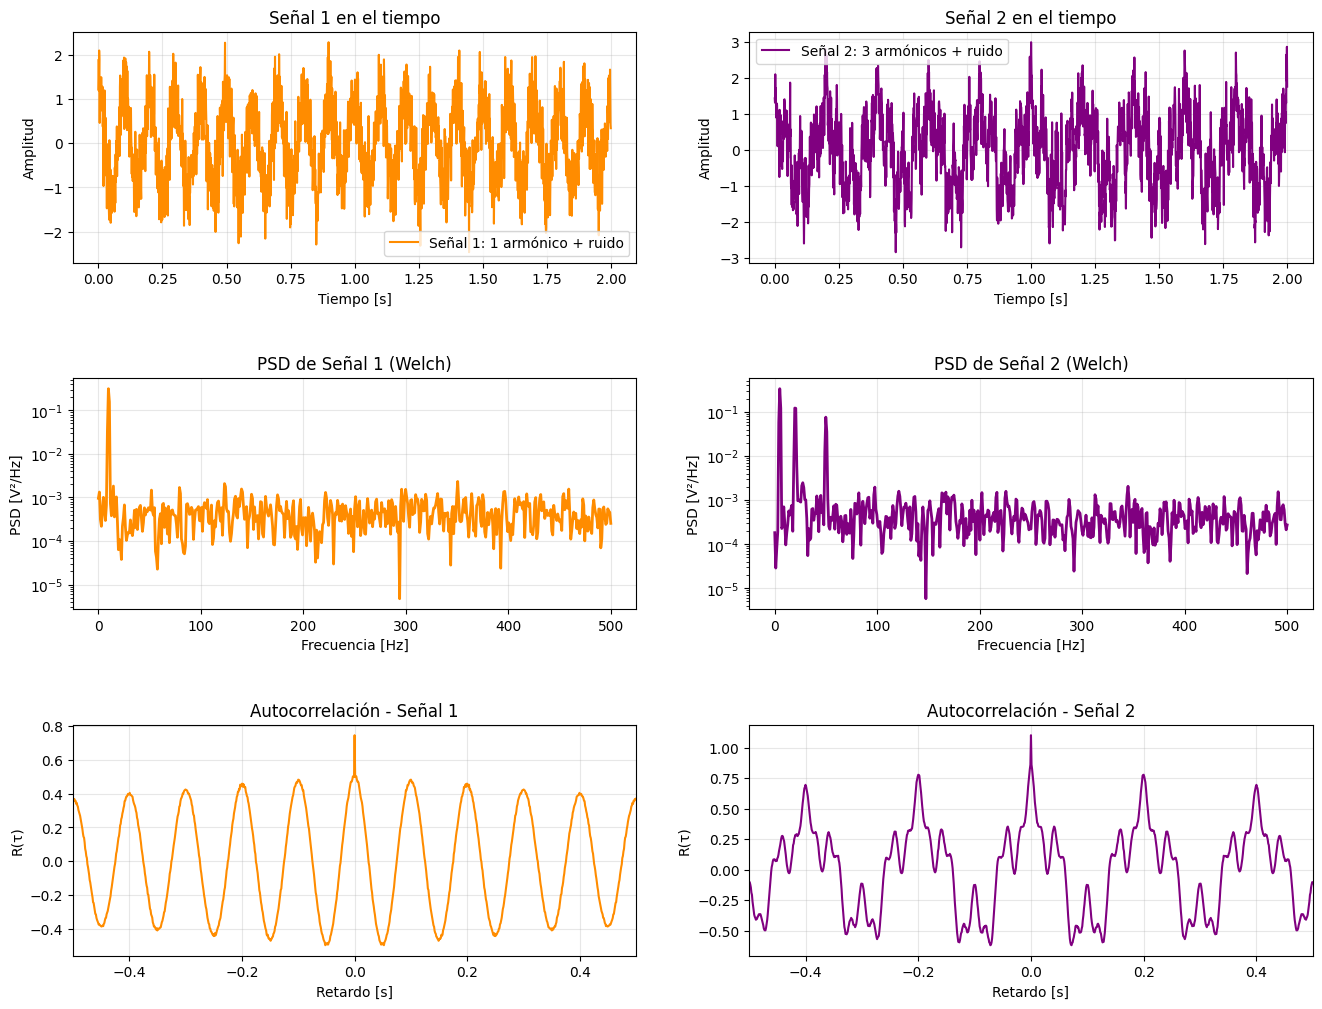

=== Resultados Estadísticos ===
Señal 1 -> Media: -0.0079, Varianza: 0.7475
Señal 2 -> Media: -0.0175, Varianza: 1.1007


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# ==============================
# Parámetros generales
# ==============================
fs = 1000          # Frecuencia de muestreo [Hz]
T = 2              # Duración [s]
t = np.linspace(0, T, int(fs*T), endpoint=False)  # Vector de tiempo
np.random.seed(0)  # Semilla reproducible

# ==============================
# Señal 1: Un armónico + ruido
# ==============================
f1 = 10   # frecuencia fundamental [Hz]
signal1 = np.cos(2*np.pi*f1*t) + 0.5*np.random.randn(len(t))

# Estadísticos
mean1 = np.mean(signal1)
var1 = np.var(signal1)

# Autocorrelación (normalizada)
autocorr1 = np.correlate(signal1 - mean1, signal1 - mean1, mode="full") / len(signal1)
lags1 = np.arange(-len(signal1)+1, len(signal1)) / fs

# PSD con Welch
f_psd1, Pxx1 = welch(signal1, fs=fs, nperseg=1024)

# ==============================
# Señal 2: Tres armónicos + ruido
# ==============================
signal2 = (np.cos(2*np.pi*5*t) + 0.7*np.cos(2*np.pi*20*t) +
           0.5*np.cos(2*np.pi*50*t) + 0.5*np.random.randn(len(t)))

# Estadísticos
mean2 = np.mean(signal2)
var2 = np.var(signal2)

# Autocorrelación (normalizada)
autocorr2 = np.correlate(signal2 - mean2, signal2 - mean2, mode="full") / len(signal2)
lags2 = np.arange(-len(signal2)+1, len(signal2)) / fs

# PSD con Welch
f_psd2, Pxx2 = welch(signal2, fs=fs, nperseg=1024)

# ==============================
# Gráficas
# ==============================
fig, axs = plt.subplots(3, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.5)

# Señales en el tiempo
axs[0,0].plot(t, signal1, color='darkorange', label="Señal 1: 1 armónico + ruido")
axs[0,0].set_title("Señal 1 en el tiempo")
axs[0,0].set_xlabel("Tiempo [s]")
axs[0,0].set_ylabel("Amplitud")
axs[0,0].legend()
axs[0,0].grid(alpha=0.3)

axs[0,1].plot(t, signal2, color='purple', label="Señal 2: 3 armónicos + ruido")
axs[0,1].set_title("Señal 2 en el tiempo")
axs[0,1].set_xlabel("Tiempo [s]")
axs[0,1].set_ylabel("Amplitud")
axs[0,1].legend()
axs[0,1].grid(alpha=0.3)

# Espectros de Potencia
axs[1,0].semilogy(f_psd1, Pxx1, color='darkorange', linewidth=2)
axs[1,0].set_title("PSD de Señal 1 (Welch)")
axs[1,0].set_xlabel("Frecuencia [Hz]")
axs[1,0].set_ylabel("PSD [V²/Hz]")
axs[1,0].grid(alpha=0.3)

axs[1,1].semilogy(f_psd2, Pxx2, color='purple', linewidth=2)
axs[1,1].set_title("PSD de Señal 2 (Welch)")
axs[1,1].set_xlabel("Frecuencia [Hz]")
axs[1,1].set_ylabel("PSD [V²/Hz]")
axs[1,1].grid(alpha=0.3)

# Autocorrelaciones
axs[2,0].plot(lags1, autocorr1, color='darkorange')
axs[2,0].set_xlim(-0.5, 0.5)
axs[2,0].set_title("Autocorrelación - Señal 1")
axs[2,0].set_xlabel("Retardo [s]")
axs[2,0].set_ylabel("R(τ)")
axs[2,0].grid(alpha=0.3)

axs[2,1].plot(lags2, autocorr2, color='purple')
axs[2,1].set_xlim(-0.5, 0.5)
axs[2,1].set_title("Autocorrelación - Señal 2")
axs[2,1].set_xlabel("Retardo [s]")
axs[2,1].set_ylabel("R(τ)")
axs[2,1].grid(alpha=0.3)

plt.show()

# ==============================
# Resultados finales
# ==============================
print("=== Resultados Estadísticos ===")
print(f"Señal 1 -> Media: {mean1:.4f}, Varianza: {var1:.4f}")
print(f"Señal 2 -> Media: {mean2:.4f}, Varianza: {var2:.4f}")
